In [1]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
from pathlib import Path

print("🔍 Dosya aranıyor...")
search_results = !find /content/drive/MyDrive -name "MultiRes_ConfocFluo_HumanDentin.zip"

if search_results:
    ZIP_PATH = search_results[0]
    print(f"✅ Bulundu: {ZIP_PATH}")
else:
    ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"

EXTRACT_PATH = "/content/dataset"
check = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified"

if check.exists():
    print("✅ Dataset zaten açık!")
else:
    print("📦 Açılıyor...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
        toplam = len(dosyalar)
        for i, d in enumerate(dosyalar):
            z.extract(d, EXTRACT_PATH)
            if i % 10000 == 0:
                print(f"  {i:,}/{toplam:,} ({i/toplam*100:.0f}%)")
    print("✅ Açıldı!")

for s in ["tubules","branches","both"]:
    print(f"  {s}/HR: {len(list((check/s/'HR').glob('*.tif'))):,}")

Mounted at /content/drive
🔍 Dosya aranıyor...
✅ Bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
📦 Açılıyor...
  0/361,873 (0%)
  10,000/361,873 (3%)
  20,000/361,873 (6%)
  30,000/361,873 (8%)
  40,000/361,873 (11%)
  50,000/361,873 (14%)
  60,000/361,873 (17%)
  70,000/361,873 (19%)
  80,000/361,873 (22%)
  90,000/361,873 (25%)
  100,000/361,873 (28%)
  110,000/361,873 (30%)
  120,000/361,873 (33%)
  130,000/361,873 (36%)
  140,000/361,873 (39%)
  150,000/361,873 (41%)
  160,000/361,873 (44%)
  170,000/361,873 (47%)
  180,000/361,873 (50%)
  190,000/361,873 (53%)
  200,000/361,873 (55%)
  210,000/361,873 (58%)
  220,000/361,873 (61%)
  230,000/361,873 (64%)
  240,000/361,873 (66%)
  250,000/361,873 (69%)
  260,000/361,873 (72%)
  270,000/361,873 (75%)
  280,000/361,873 (77%)
  290,000/361,873 (80%)
  300,000/361,873 (83%)
  310,000/361,873 (86%)
  320,000/361,873 (88%)
  330,000/361,873 (91%)
  340,000/361,873 (94%)
  350,000/361,873 (97%)
  360,000/361,873 (99%)
✅

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path
import tifffile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import warnings
warnings.filterwarnings('ignore')

DEVICE       = torch.device("cuda")
PATCHES_ROOT = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR     = ["tubules", "branches", "both"]
SINIF2IDX    = {s: i for i, s in enumerate(SINIFLAR)}
IDX2SINIF    = {i: s for s, i in SINIF2IDX.items()}
TEST_ROIS    = ["roi06"]
COZUNURLUKLER = ["HR", "x2", "x4", "x8"]

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            if get_roi(tif.name) in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

class DentinDataset(Dataset):
    def __init__(self, dosya_listesi):
        self.dosya_listesi = dosya_listesi
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        return self.tf(img), torch.tensor(etiket, dtype=torch.long), yol

def efficientnet_olustur():
    m = models.efficientnet_b0(weights=None)
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(True),
        nn.Dropout(0.2),
        nn.Linear(256, 3)
    )

    return m
  # Hücre 2'nin sonuna ekle
MODEL_DIR = Path("/content/drive/MyDrive")
print("\n🔍 Drive'da model dosyaları aranıyor...")
for coz in COZUNURLUKLER:
    dosya = MODEL_DIR / f"effnet_best_{coz}.pth"
    if dosya.exists():
        print(f"  ✅ {coz}: bulundu")
    else:
        print(f"  ❌ {coz}: bulunamadı → yeniden eğitim gerekli")

print(f"✅ Device: {DEVICE} ({torch.cuda.get_device_name(0)})")
print("✅ Kurulum tamamlandı!")


🔍 Drive'da model dosyaları aranıyor...
  ✅ HR: bulundu
  ✅ x2: bulundu
  ✅ x4: bulundu
  ✅ x8: bulundu
✅ Device: cuda (NVIDIA A100-SXM4-40GB)
✅ Kurulum tamamlandı!


In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.target_layer = target_layer
        self.gradients   = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Ağırlıkları hesapla
        weights      = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam          = (weights * self.activations).sum(dim=1, keepdim=True)
        cam          = torch.relu(cam)
        cam          = cam.squeeze().cpu().numpy()

        # 128×128'e yeniden boyutlandır
        cam = cv2.resize(cam, (128, 128))
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        probs = torch.softmax(output, dim=1)[0].detach().cpu().numpy()
        return cam, class_idx, probs

def goruntu_denormalize(tensor):
    """Normalize edilmiş tensoru görüntüye çevirir"""
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    img = np.clip(img, 0, 1)
    return img

print("✅ Grad-CAM sınıfı hazır!")

✅ Grad-CAM sınıfı hazır!


✅ HR modeli yüklendi
✅ x2 modeli yüklendi
✅ x4 modeli yüklendi
✅ x8 modeli yüklendi


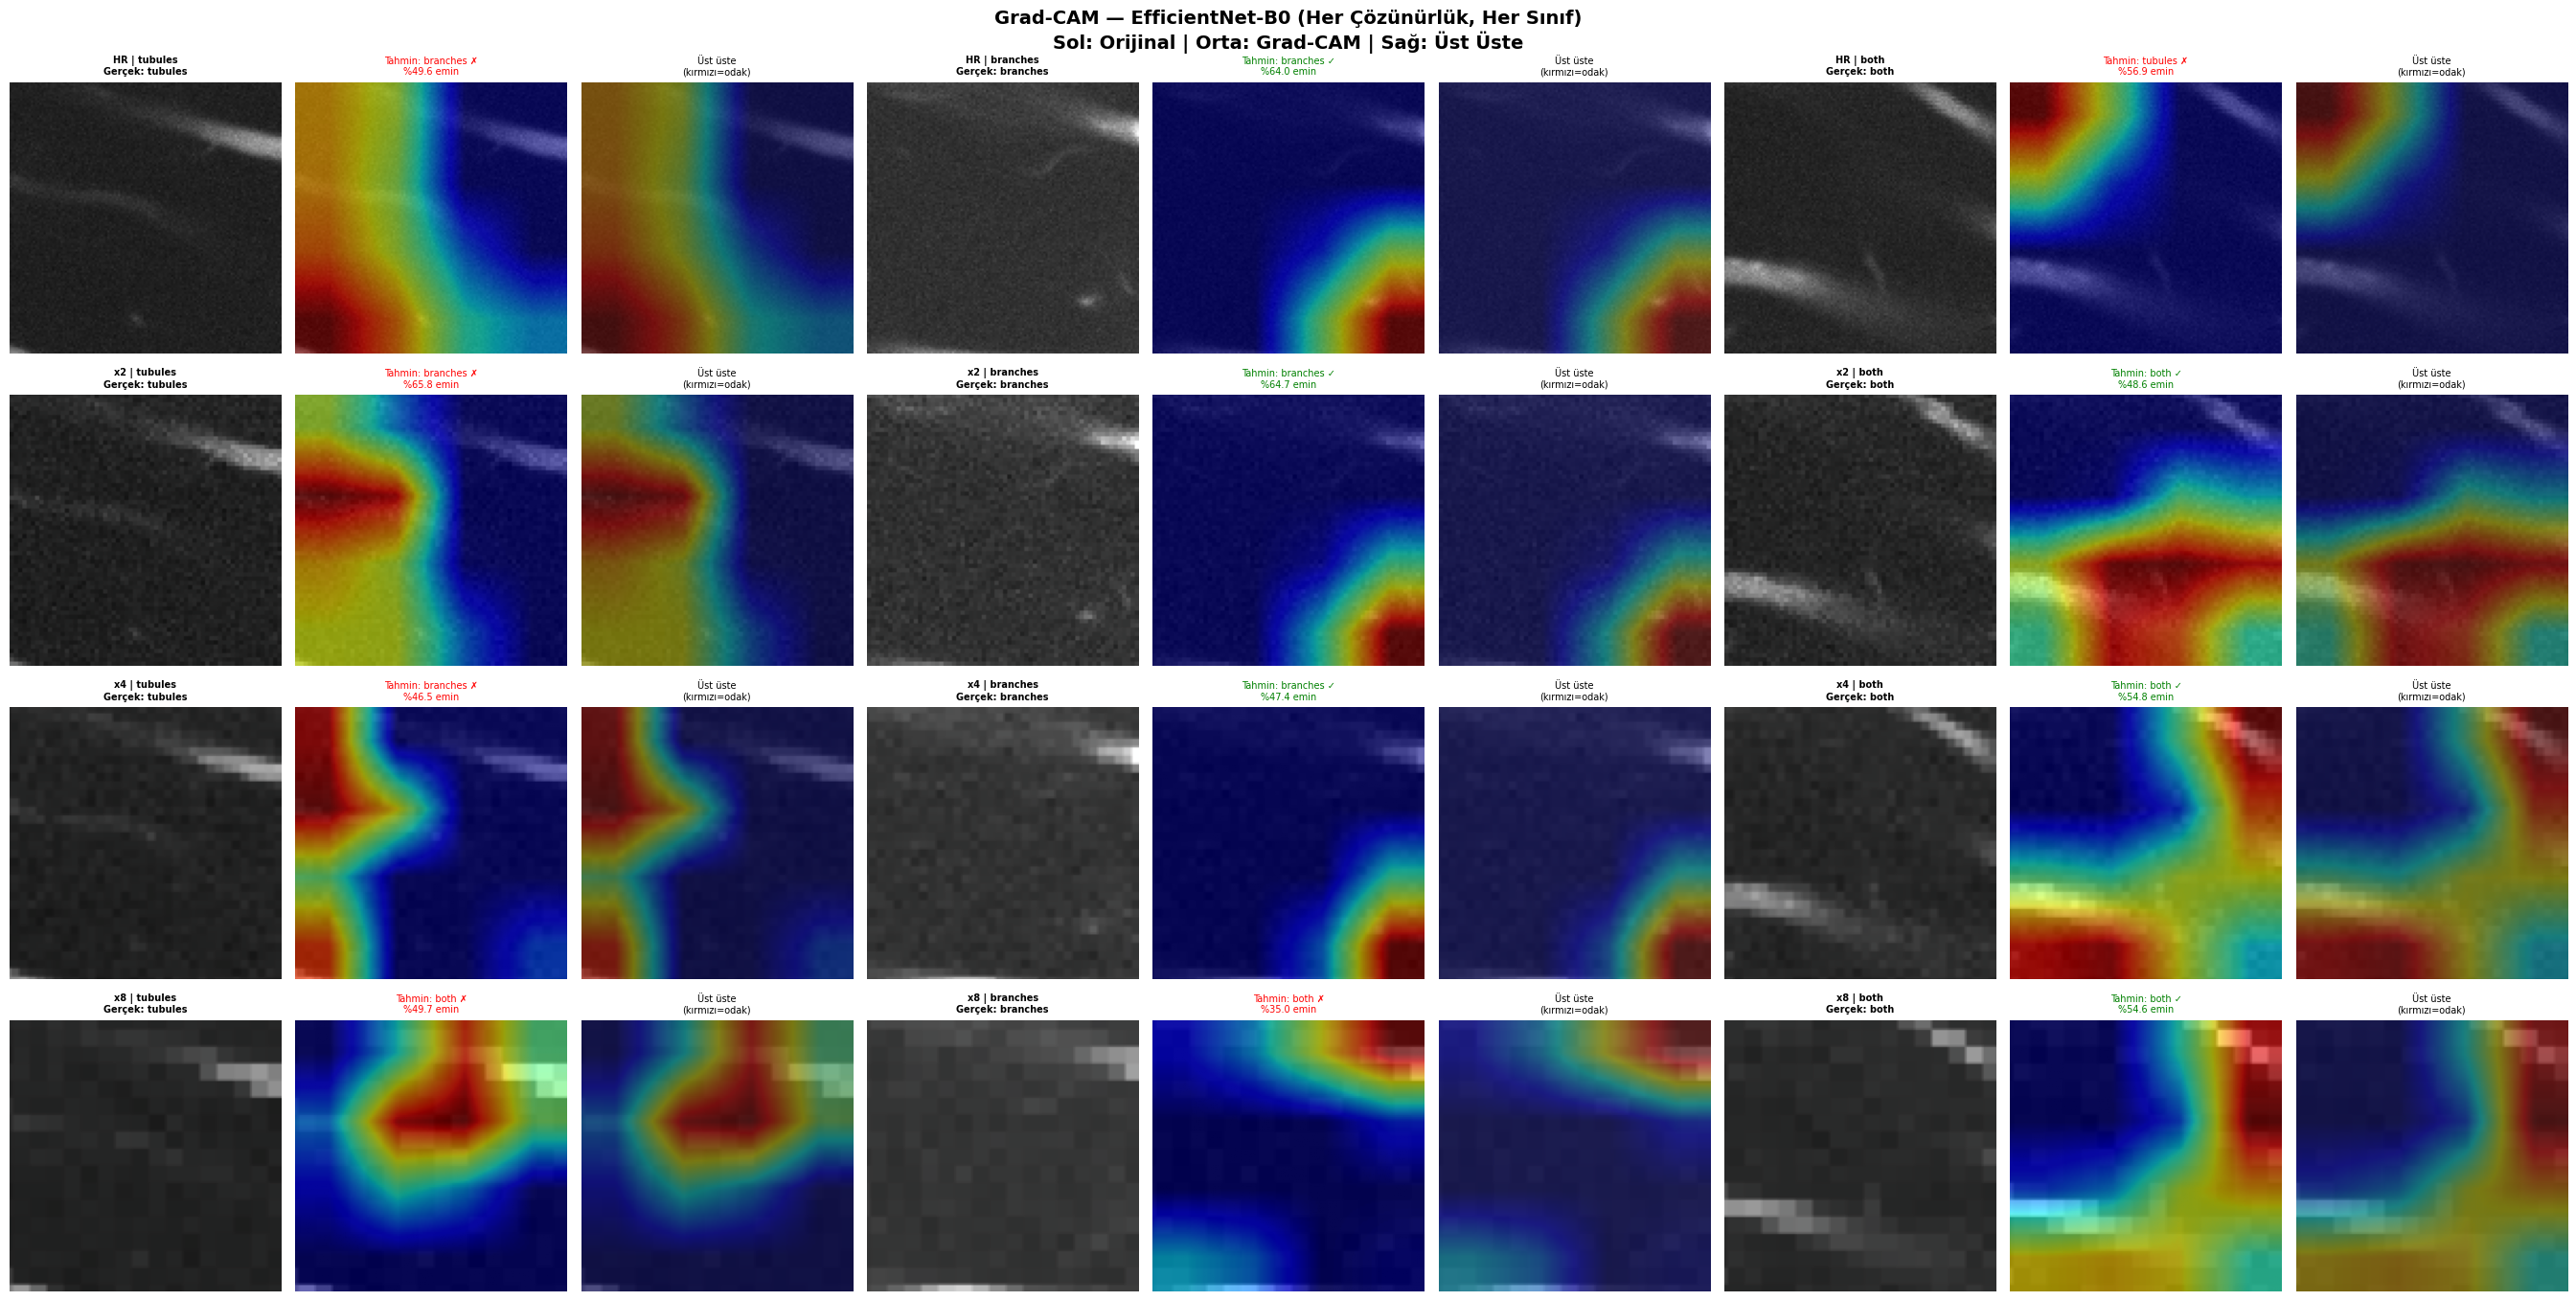

✅ Grad-CAM görseli kaydedildi!


In [4]:
SINIF_RENKLERI = {"tubules": "#E74C3C", "branches": "#27AE60", "both": "#2980B9"}

fig, axes = plt.subplots(4, 9, figsize=(27, 14))
fig.suptitle("Grad-CAM — EfficientNet-B0 (Her Çözünürlük, Her Sınıf)\n"
             "Sol: Orijinal | Orta: Grad-CAM | Sağ: Üst Üste",
             fontsize=14, fontweight='bold')

for row, coz in enumerate(COZUNURLUKLER):
    # Modeli yükle
    model_yol = f"/content/drive/MyDrive/effnet_best_{coz}.pth"
    if not Path(model_yol).exists():
        # Colab'ın kendi dizininde ara
        model_yol = f"effnet_best_{coz}.pth"

    model = efficientnet_olustur().to(DEVICE)
    try:
        model.load_state_dict(torch.load(model_yol, map_location=DEVICE))
        print(f"✅ {coz} modeli yüklendi")
    except:
        print(f"❌ {coz} modeli bulunamadı: {model_yol}")
        continue

    # EfficientNet'in son conv katmanı
    target_layer = model.features[-1][0]
    grad_cam = GradCAM(model, target_layer)

    # Test setinden her sınıftan 1 örnek al
    dosya_listesi = build_file_list(PATCHES_ROOT, SINIFLAR, coz, TEST_ROIS)
    dataset = DentinDataset(dosya_listesi)

    # Her sınıftan bir örnek bul
    sinif_ornekleri = {}
    for tensor, etiket, yol in dataset:
        s = IDX2SINIF[etiket.item()]
        if s not in sinif_ornekleri:
            sinif_ornekleri[s] = (tensor, etiket.item(), yol)
        if len(sinif_ornekleri) == 3:
            break

    # Her sınıf için görselleştir
    for col_group, sinif in enumerate(SINIFLAR):
        if sinif not in sinif_ornekleri:
            continue

        tensor, gercek_idx, yol = sinif_ornekleri[sinif]
        cam, tahmin_idx, probs = grad_cam.generate(tensor)

        img_orig = goruntu_denormalize(tensor)
        img_gray = np.mean(img_orig, axis=2)

        # Grad-CAM ısı haritası
        heatmap = cv2.applyColorMap(
            (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

        # Üst üste bindirme
        overlay = 0.5 * img_orig + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        # Subplot sütunları: 3 sınıf × 3 görüntü (orig, cam, overlay)
        base_col = col_group * 3

        # Orijinal
        axes[row, base_col].imshow(img_orig)
        axes[row, base_col].set_title(
            f"{coz} | {sinif}\nGerçek: {SINIFLAR[gercek_idx]}",
            fontsize=7, fontweight='bold')
        axes[row, base_col].axis('off')

        # Grad-CAM
        axes[row, base_col+1].imshow(img_gray, cmap='gray')
        axes[row, base_col+1].imshow(cam, cmap='jet', alpha=0.6)
        dogruluk = "✓" if tahmin_idx == gercek_idx else "✗"
        axes[row, base_col+1].set_title(
            f"Tahmin: {SINIFLAR[tahmin_idx]} {dogruluk}\n"
            f"%{probs[tahmin_idx]*100:.1f} emin",
            fontsize=7,
            color='green' if tahmin_idx == gercek_idx else 'red')
        axes[row, base_col+1].axis('off')

        # Overlay
        axes[row, base_col+2].imshow(overlay)
        axes[row, base_col+2].set_title(
            f"Üst üste\n(kırmızı=odak)",
            fontsize=7)
        axes[row, base_col+2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_4cozunurluk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM görseli kaydedildi!")

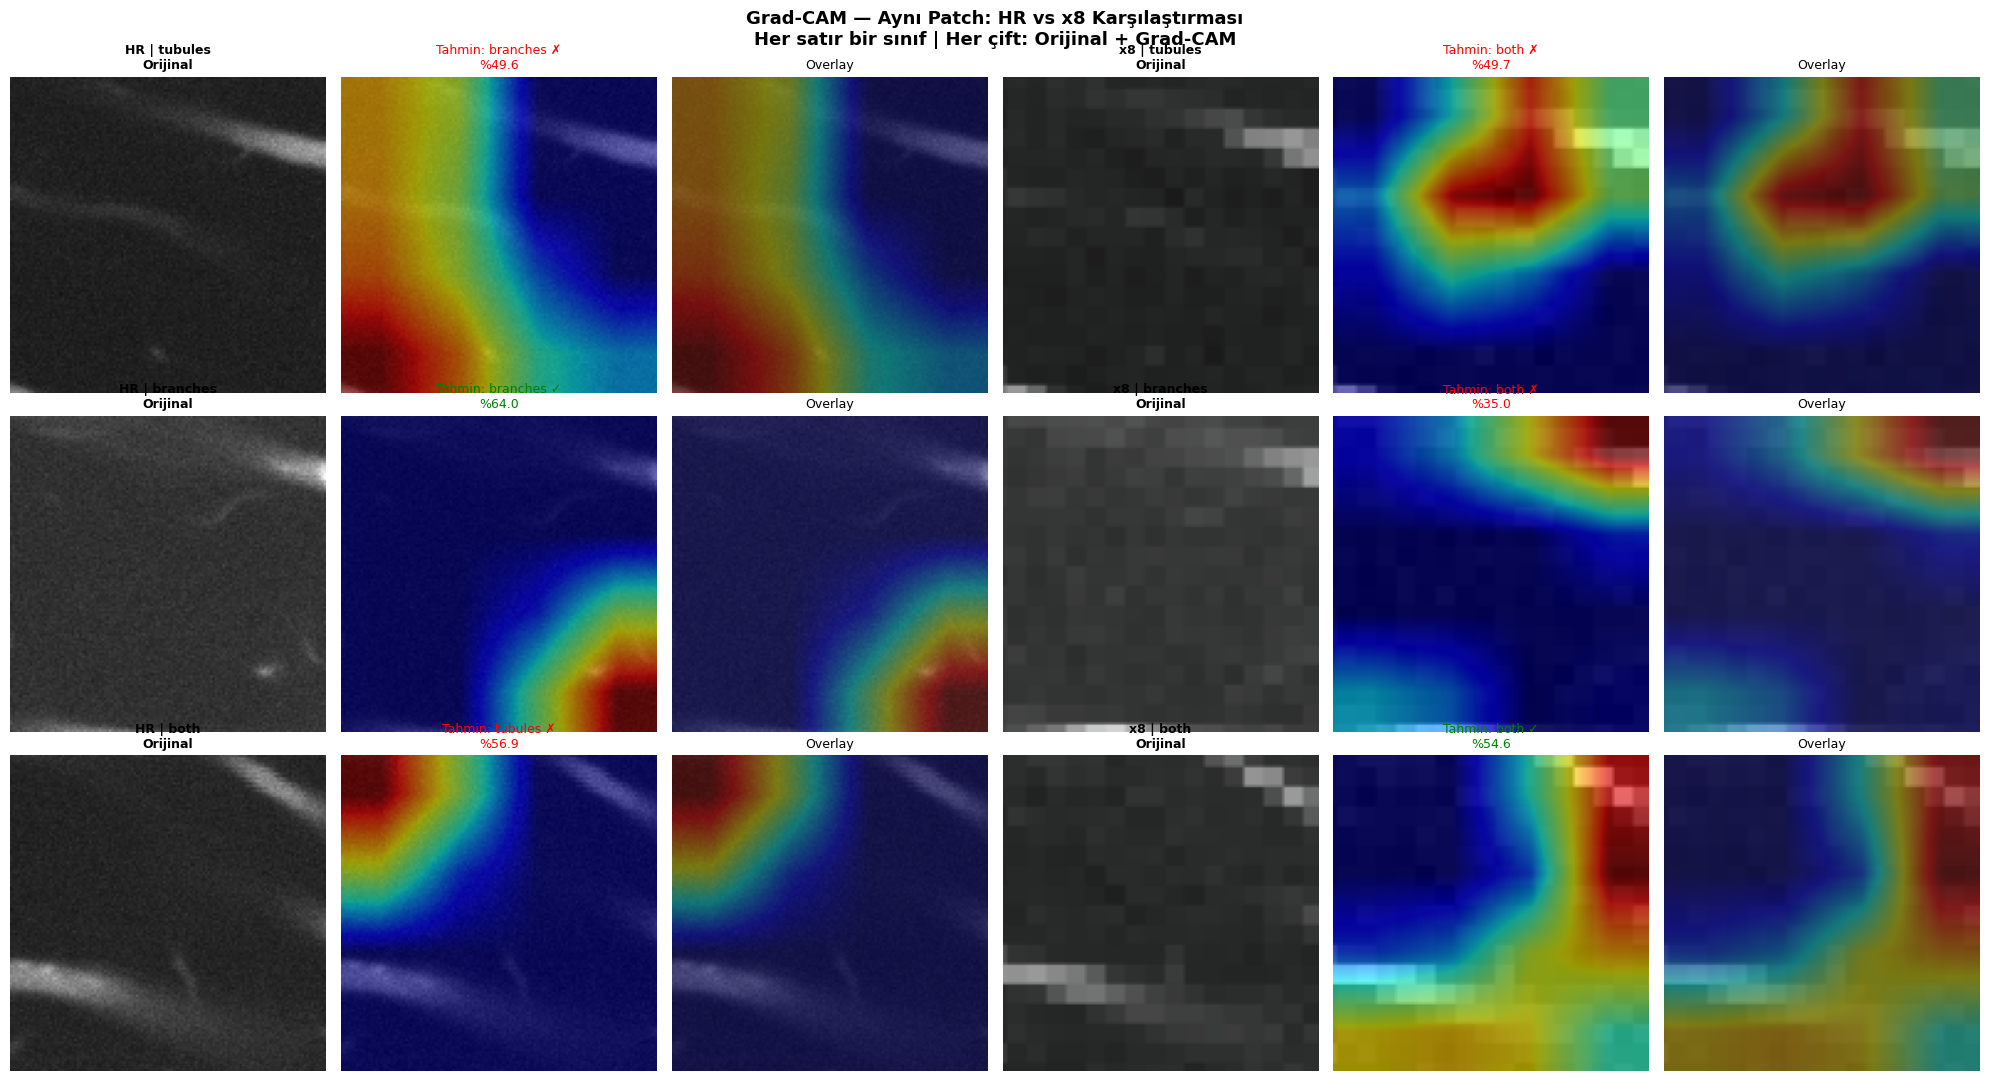

✅ HR vs x8 Grad-CAM karşılaştırması kaydedildi!


In [6]:
# Aynı patch'i HR ve x8'de karşılaştır
fig, axes = plt.subplots(3, 6, figsize=(20, 11))
fig.suptitle("Grad-CAM — Aynı Patch: HR vs x8 Karşılaştırması\n"
             "Her satır bir sınıf | Her çift: Orijinal + Grad-CAM",
             fontsize=13, fontweight='bold')

for row, sinif in enumerate(SINIFLAR):
    for col_group, coz in enumerate(["HR", "x8"]):
        model_yol = f"/content/drive/MyDrive/effnet_best_{coz}.pth"
        model = efficientnet_olustur().to(DEVICE)
        try:
            model.load_state_dict(torch.load(model_yol, map_location=DEVICE))
        except:
            print(f"❌ {coz} modeli bulunamadı")
            continue

        target_layer = model.features[-1][0]
        grad_cam = GradCAM(model, target_layer)

        dosya_listesi = build_file_list(PATCHES_ROOT, [sinif], coz, TEST_ROIS)
        dataset = DentinDataset(dosya_listesi)

        # İlk örneği al
        tensor, etiket, yol = dataset[0]
        cam, tahmin_idx, probs = grad_cam.generate(tensor)
        img_orig = goruntu_denormalize(tensor)
        img_gray = np.mean(img_orig, axis=2)

        base_col = col_group * 3

        # Orijinal
        axes[row, base_col].imshow(img_orig)
        axes[row, base_col].set_title(
            f"{coz} | {sinif}\nOrijinal", fontsize=9, fontweight='bold')
        axes[row, base_col].axis('off')

        # Grad-CAM
        axes[row, base_col+1].imshow(img_gray, cmap='gray')
        axes[row, base_col+1].imshow(cam, cmap='jet', alpha=0.6)
        dogruluk = "✓" if tahmin_idx == SINIF2IDX[sinif] else "✗"
        axes[row, base_col+1].set_title(
            f"Tahmin: {SINIFLAR[tahmin_idx]} {dogruluk}\n"
            f"%{probs[tahmin_idx]*100:.1f}",
            fontsize=9,
            color='green' if tahmin_idx == SINIF2IDX[sinif] else 'red')
        axes[row, base_col+1].axis('off')

        # Overlay
        heatmap = cv2.applyColorMap(
            (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay = np.clip(0.5*img_orig + 0.4*heatmap, 0, 1)
        axes[row, base_col+2].imshow(overlay)
        axes[row, base_col+2].set_title("Overlay", fontsize=9)
        axes[row, base_col+2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_hr_vs_x8.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ HR vs x8 Grad-CAM karşılaştırması kaydedildi!")

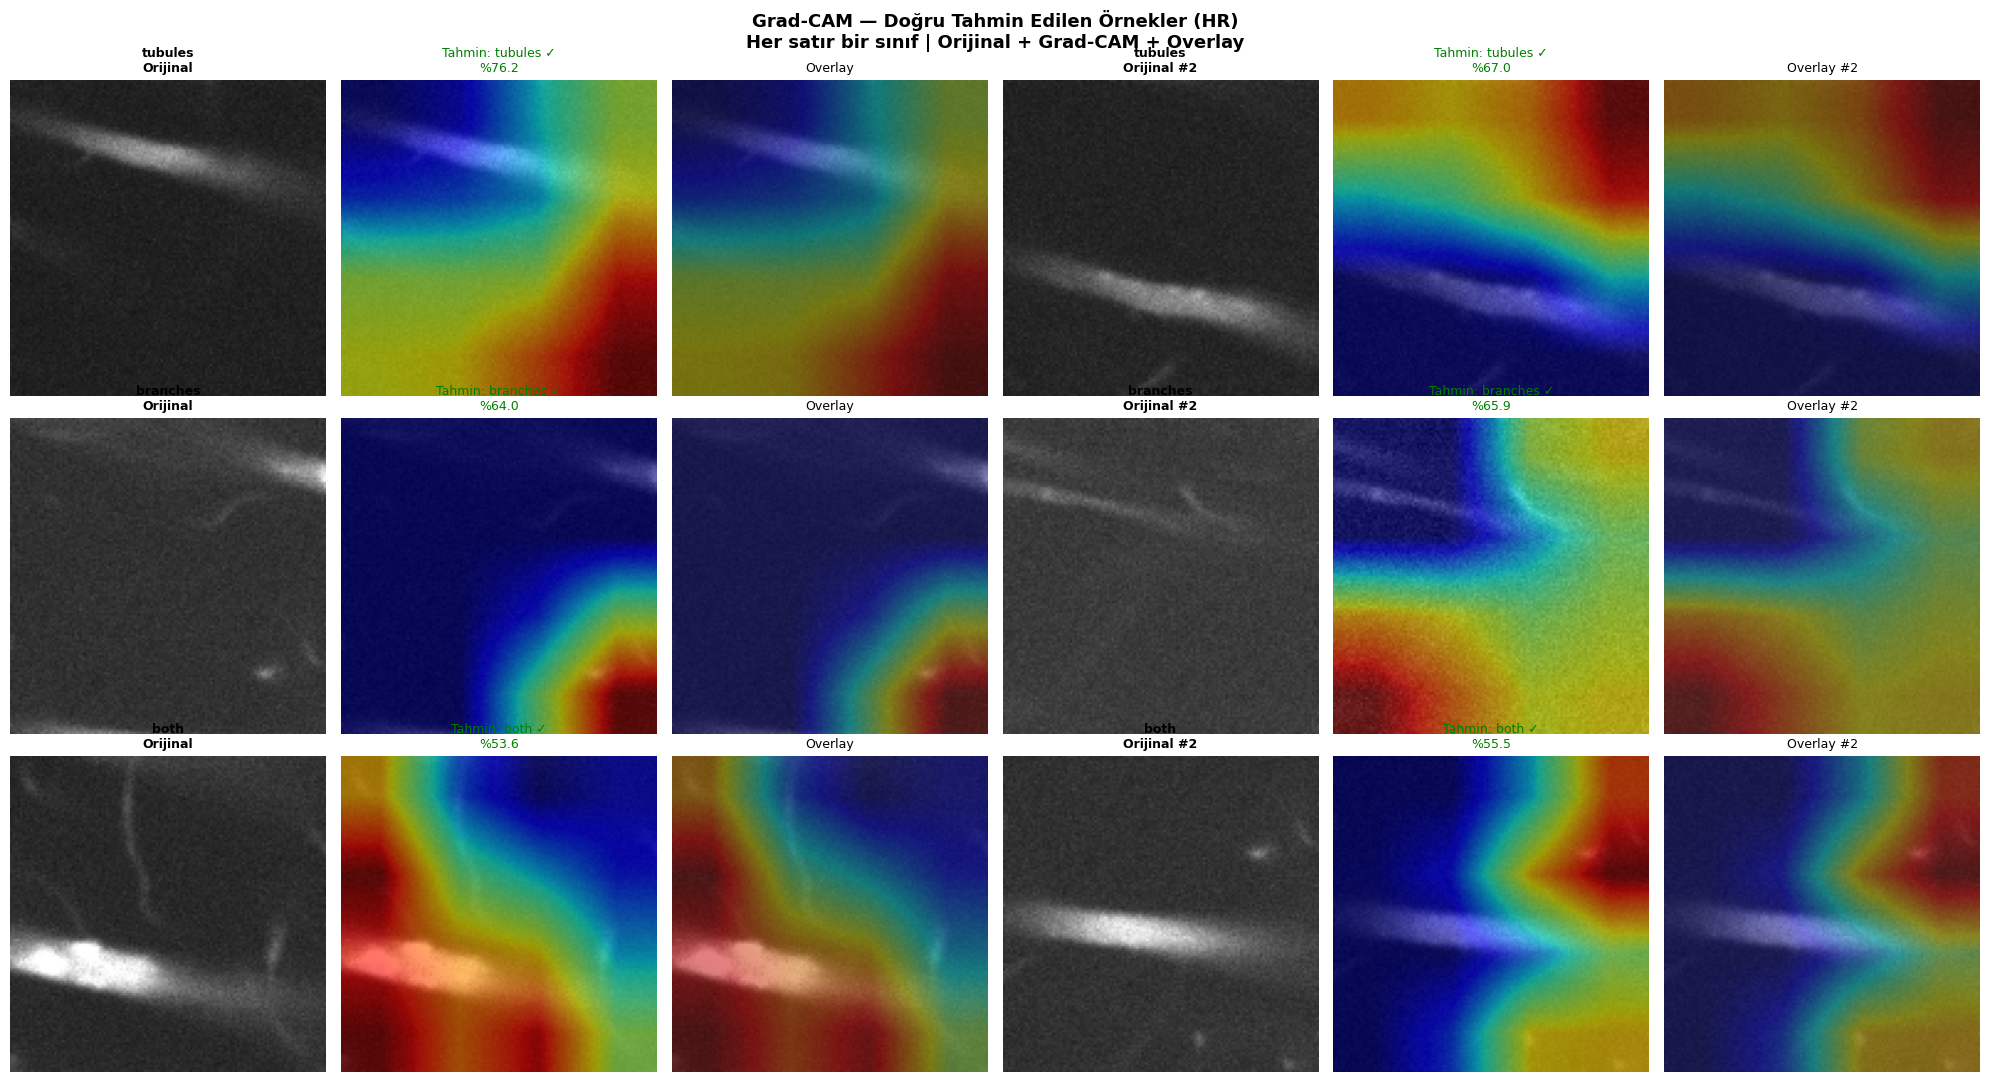

✅ Doğru tahminler Grad-CAM kaydedildi!


In [7]:
# ============================================================
# HÜCRE 6: DOĞRU TAHMİN EDİLEN ÖRNEKLER + GRAD-CAM
# ============================================================
fig, axes = plt.subplots(3, 6, figsize=(20, 11))
fig.suptitle("Grad-CAM — Doğru Tahmin Edilen Örnekler (HR)\n"
             "Her satır bir sınıf | Orijinal + Grad-CAM + Overlay",
             fontsize=13, fontweight='bold')

model_yol = f"/content/drive/MyDrive/effnet_best_HR.pth"
model = efficientnet_olustur().to(DEVICE)
model.load_state_dict(torch.load(model_yol, map_location=DEVICE))
target_layer = model.features[-1][0]
grad_cam = GradCAM(model, target_layer)

dosya_listesi = build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TEST_ROIS)
dataset = DentinDataset(dosya_listesi)

# Her sınıftan 2 DOĞRU tahmin edilen örnek bul
sinif_ornekleri = {s: [] for s in SINIFLAR}
for tensor, etiket, yol in dataset:
    sinif = IDX2SINIF[etiket.item()]
    if len(sinif_ornekleri[sinif]) >= 2:
        continue
    cam, tahmin_idx, probs = grad_cam.generate(tensor)
    if tahmin_idx == etiket.item():  # Sadece doğru tahminler
        sinif_ornekleri[sinif].append((tensor, etiket.item(), cam, probs))
    if all(len(v) >= 2 for v in sinif_ornekleri.values()):
        break

for row, sinif in enumerate(SINIFLAR):
    ornekler = sinif_ornekleri[sinif]
    if not ornekler:
        continue
    tensor, gercek_idx, cam, probs = ornekler[0]
    img_orig = goruntu_denormalize(tensor)
    img_gray = np.mean(img_orig, axis=2)
    heatmap  = cv2.applyColorMap(
        (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay  = np.clip(0.5*img_orig + 0.4*heatmap, 0, 1)

    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title(f"{sinif}\nOrijinal", fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_gray, cmap='gray')
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.6)
    axes[row, 1].set_title(f"Tahmin: {sinif} ✓\n%{probs[gercek_idx]*100:.1f}",
                           fontsize=9, color='green')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay", fontsize=9)
    axes[row, 2].axis('off')

    # İkinci örnek
    if len(ornekler) > 1:
        tensor2, gercek_idx2, cam2, probs2 = ornekler[1]
        img_orig2 = goruntu_denormalize(tensor2)
        img_gray2 = np.mean(img_orig2, axis=2)
        heatmap2  = cv2.applyColorMap(
            (cam2 * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap2  = cv2.cvtColor(heatmap2, cv2.COLOR_BGR2RGB) / 255.0
        overlay2  = np.clip(0.5*img_orig2 + 0.4*heatmap2, 0, 1)

        axes[row, 3].imshow(img_orig2)
        axes[row, 3].set_title(f"{sinif}\nOrijinal #2", fontsize=9, fontweight='bold')
        axes[row, 3].axis('off')

        axes[row, 4].imshow(img_gray2, cmap='gray')
        axes[row, 4].imshow(cam2, cmap='jet', alpha=0.6)
        axes[row, 4].set_title(f"Tahmin: {sinif} ✓\n%{probs2[gercek_idx2]*100:.1f}",
                               fontsize=9, color='green')
        axes[row, 4].axis('off')

        axes[row, 5].imshow(overlay2)
        axes[row, 5].set_title("Overlay #2", fontsize=9)
        axes[row, 5].axis('off')

plt.tight_layout()
plt.savefig("gradcam_dogru_tahminler.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Doğru tahminler Grad-CAM kaydedildi!")

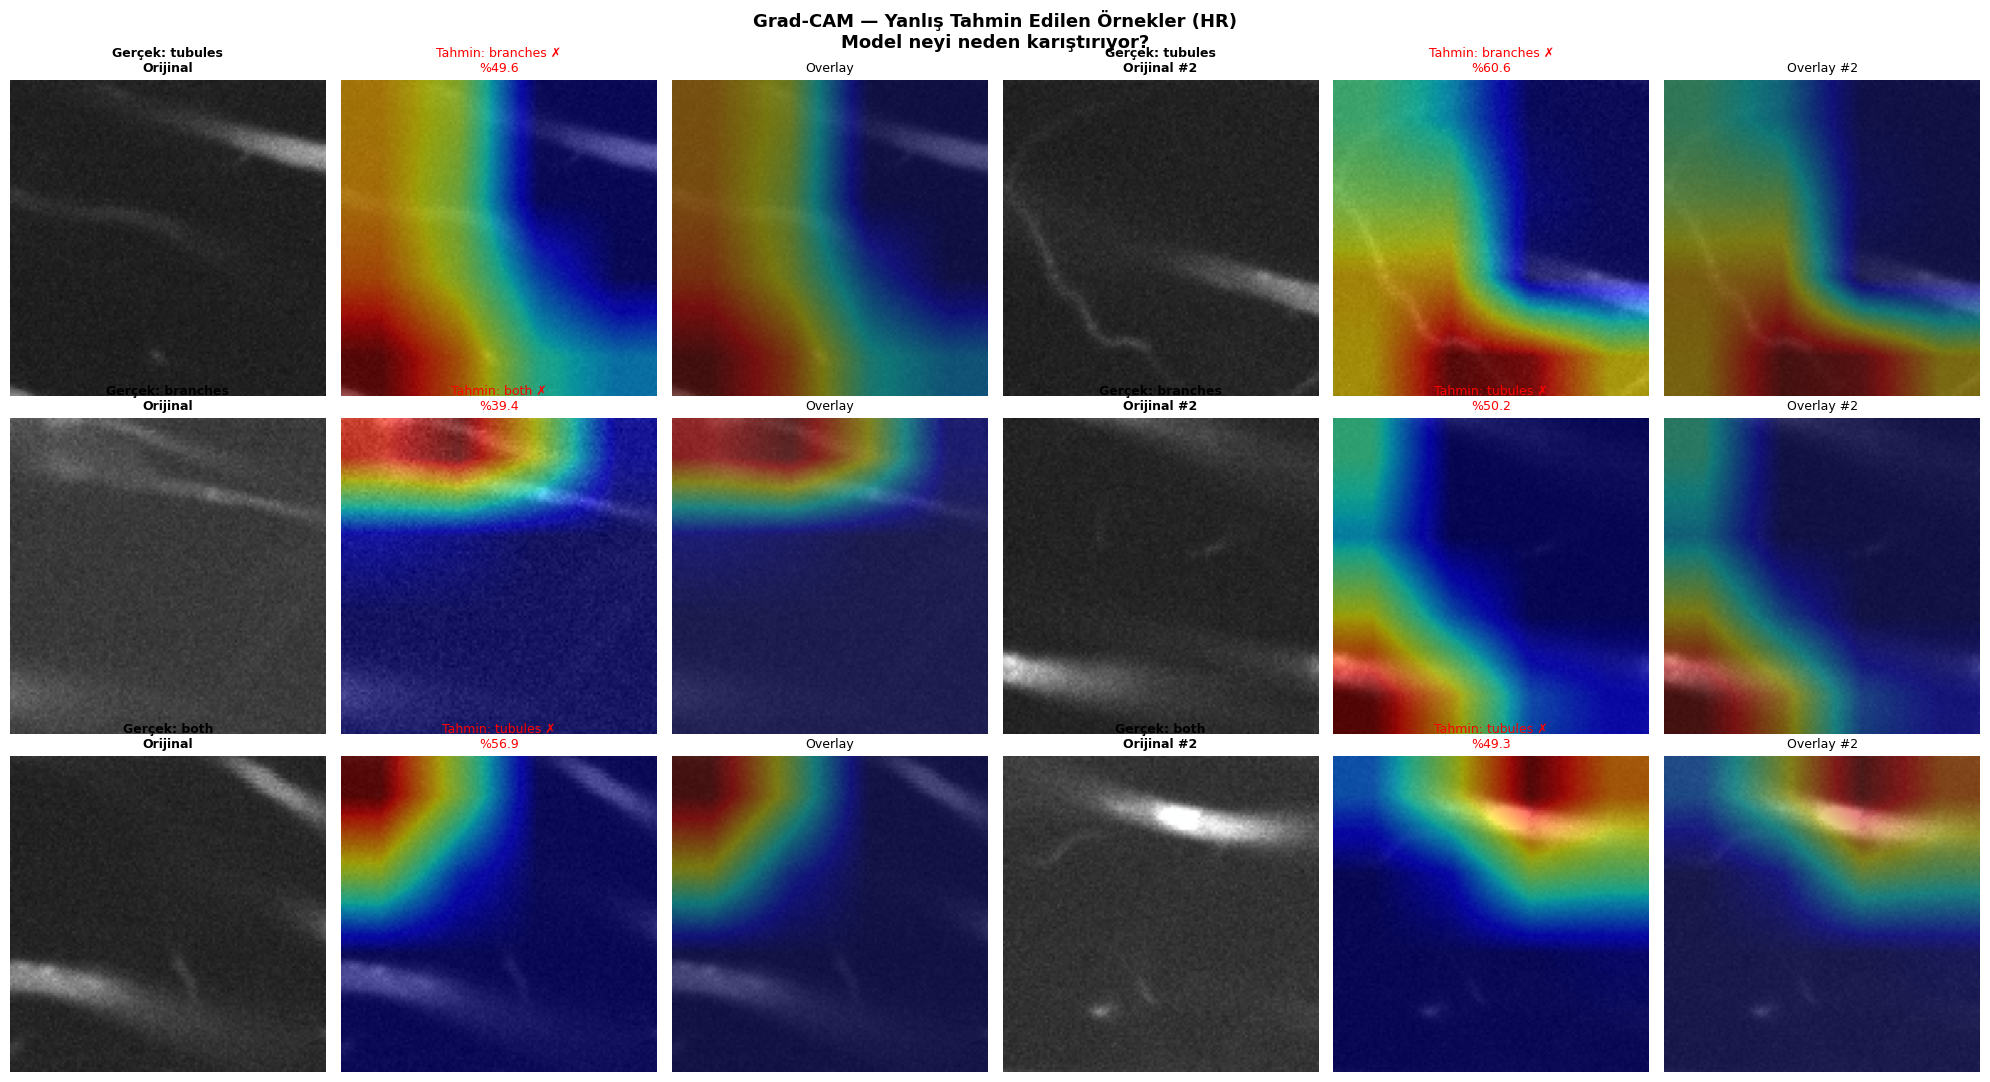

✅ Yanlış tahminler Grad-CAM kaydedildi!


In [8]:
# ============================================================
# HÜCRE 7: YANLIŞ TAHMİNLERİN ANALİZİ
# ============================================================
fig, axes = plt.subplots(3, 6, figsize=(20, 11))
fig.suptitle("Grad-CAM — Yanlış Tahmin Edilen Örnekler (HR)\n"
             "Model neyi neden karıştırıyor?",
             fontsize=13, fontweight='bold')

# Aynı HR modelini kullan
yanlis_ornekler = {s: [] for s in SINIFLAR}
for tensor, etiket, yol in dataset:
    sinif = IDX2SINIF[etiket.item()]
    if len(yanlis_ornekler[sinif]) >= 2:
        continue
    cam, tahmin_idx, probs = grad_cam.generate(tensor)
    if tahmin_idx != etiket.item():  # Sadece yanlış tahminler
        yanlis_ornekler[sinif].append(
            (tensor, etiket.item(), tahmin_idx, cam, probs))
    if all(len(v) >= 2 for v in yanlis_ornekler.values()):
        break

for row, sinif in enumerate(SINIFLAR):
    ornekler = yanlis_ornekler[sinif]
    if not ornekler:
        axes[row, 0].text(0.5, 0.5, f"{sinif}\nYanlış örnek\nbulunamadı",
                         ha='center', va='center', transform=axes[row,0].transAxes)
        for col in range(6):
            axes[row, col].axis('off')
        continue

    tensor, gercek_idx, tahmin_idx, cam, probs = ornekler[0]
    img_orig = goruntu_denormalize(tensor)
    img_gray = np.mean(img_orig, axis=2)
    heatmap  = cv2.applyColorMap(
        (cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap  = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay  = np.clip(0.5*img_orig + 0.4*heatmap, 0, 1)

    axes[row, 0].imshow(img_orig)
    axes[row, 0].set_title(
        f"Gerçek: {sinif}\nOrijinal", fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(img_gray, cmap='gray')
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.6)
    axes[row, 1].set_title(
        f"Tahmin: {IDX2SINIF[tahmin_idx]} ✗\n%{probs[tahmin_idx]*100:.1f}",
        fontsize=9, color='red')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Overlay", fontsize=9)
    axes[row, 2].axis('off')

    if len(ornekler) > 1:
        tensor2, gercek_idx2, tahmin_idx2, cam2, probs2 = ornekler[1]
        img_orig2 = goruntu_denormalize(tensor2)
        img_gray2 = np.mean(img_orig2, axis=2)
        heatmap2  = cv2.applyColorMap(
            (cam2 * 255).astype(np.uint8), cv2.COLORMAP_JET)
        heatmap2  = cv2.cvtColor(heatmap2, cv2.COLOR_BGR2RGB) / 255.0
        overlay2  = np.clip(0.5*img_orig2 + 0.4*heatmap2, 0, 1)

        axes[row, 3].imshow(img_orig2)
        axes[row, 3].set_title(
            f"Gerçek: {sinif}\nOrijinal #2", fontsize=9, fontweight='bold')
        axes[row, 3].axis('off')

        axes[row, 4].imshow(img_gray2, cmap='gray')
        axes[row, 4].imshow(cam2, cmap='jet', alpha=0.6)
        axes[row, 4].set_title(
            f"Tahmin: {IDX2SINIF[tahmin_idx2]} ✗\n%{probs2[tahmin_idx2]*100:.1f}",
            fontsize=9, color='red')
        axes[row, 4].axis('off')

        axes[row, 5].imshow(overlay2)
        axes[row, 5].set_title("Overlay #2", fontsize=9)
        axes[row, 5].axis('off')

plt.tight_layout()
plt.savefig("gradcam_yanlis_tahminler.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Yanlış tahminler Grad-CAM kaydedildi!")

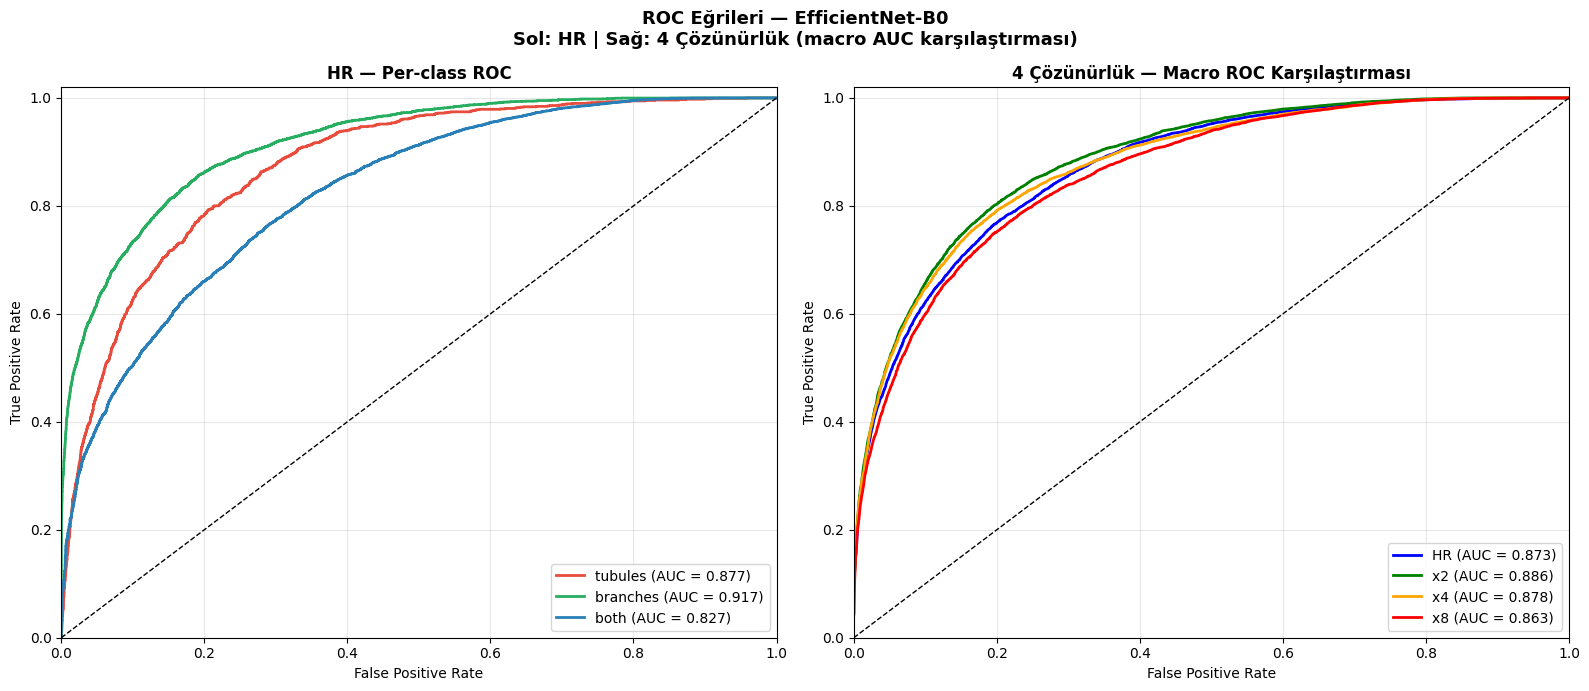

✅ ROC eğrileri kaydedildi!


In [9]:
# ============================================================
# HÜCRE 8: ROC EĞRİLERİ — HR MODELİ
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

# Test seti tahminlerini topla
class DentinDatasetSimple(Dataset):
    def __init__(self, dosya_listesi):
        self.dosya_listesi = dosya_listesi
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        return self.tf(img), torch.tensor(etiket, dtype=torch.long)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ROC Eğrileri — EfficientNet-B0\n"
             "Sol: HR | Sağ: 4 Çözünürlük (macro AUC karşılaştırması)",
             fontsize=13, fontweight='bold')

RENKLER = ['#E74C3C', '#27AE60', '#2980B9']
COZ_RENKLER = {'HR': 'blue', 'x2': 'green', 'x4': 'orange', 'x8': 'red'}

# Sol — HR için per-class ROC
model = efficientnet_olustur().to(DEVICE)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/effnet_best_HR.pth", map_location=DEVICE))
model.eval()

test_list = build_file_list(PATCHES_ROOT, SINIFLAR, "HR", TEST_ROIS)
test_ds   = DentinDatasetSimple(test_list)
test_ld   = DataLoader(test_ds, 64, shuffle=False, num_workers=2)

tum_prob, tum_gercek = [], []
with torch.no_grad():
    for imgs, eti in test_ld:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        prob = torch.softmax(out, dim=1).cpu().numpy()
        tum_prob.extend(prob)
        tum_gercek.extend(eti.numpy())

tum_prob   = np.array(tum_prob)
tum_gercek = np.array(tum_gercek)
y_bin      = label_binarize(tum_gercek, classes=[0, 1, 2])

for i, sinif in enumerate(SINIFLAR):
    fpr, tpr, _ = roc_curve(y_bin[:, i], tum_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=RENKLER[i], lw=2,
                 label=f"{sinif} (AUC = {roc_auc:.3f})")

axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("HR — Per-class ROC", fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(True, alpha=0.3)

# Sağ — 4 çözünürlük macro AUC karşılaştırması
for coz in COZUNURLUKLER:
    try:
        m = efficientnet_olustur().to(DEVICE)
        m.load_state_dict(torch.load(
            f"/content/drive/MyDrive/effnet_best_{coz}.pth", map_location=DEVICE))
        m.eval()

        test_list_c = build_file_list(PATCHES_ROOT, SINIFLAR, coz, TEST_ROIS)
        test_ds_c   = DentinDatasetSimple(test_list_c)
        test_ld_c   = DataLoader(test_ds_c, 64, shuffle=False, num_workers=2)

        prob_c, gercek_c = [], []
        with torch.no_grad():
            for imgs, eti in test_ld_c:
                imgs = imgs.to(DEVICE)
                out  = m(imgs)
                prob_c.extend(torch.softmax(out, dim=1).cpu().numpy())
                gercek_c.extend(eti.numpy())

        prob_c   = np.array(prob_c)
        gercek_c = np.array(gercek_c)
        y_bin_c  = label_binarize(gercek_c, classes=[0, 1, 2])

        # Macro ROC
        fpr_all, tpr_all = [], []
        for i in range(3):
            fpr_i, tpr_i, _ = roc_curve(y_bin_c[:, i], prob_c[:, i])
            fpr_all.append(fpr_i); tpr_all.append(tpr_i)
        all_fpr = np.unique(np.concatenate(fpr_all))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(3):
            mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
        mean_tpr /= 3
        macro_auc = auc(all_fpr, mean_tpr)

        axes[1].plot(all_fpr, mean_tpr, color=COZ_RENKLER[coz], lw=2,
                     label=f"{coz} (AUC = {macro_auc:.3f})")
    except Exception as e:
        print(f"❌ {coz}: {e}")

axes[1].plot([0,1], [0,1], 'k--', lw=1)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("4 Çözünürlük — Macro ROC Karşılaştırması", fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_egrileri.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC eğrileri kaydedildi!")